In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pickle
import random
from random import shuffle
import time
import sys
from sine_models import *
sys.path.append("..")
from neurons import *

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
random.seed(42)
with open('sine_dataset.pkl', 'rb') as f:
    train_data, train_label, val_data, val_label = pickle.load(f)

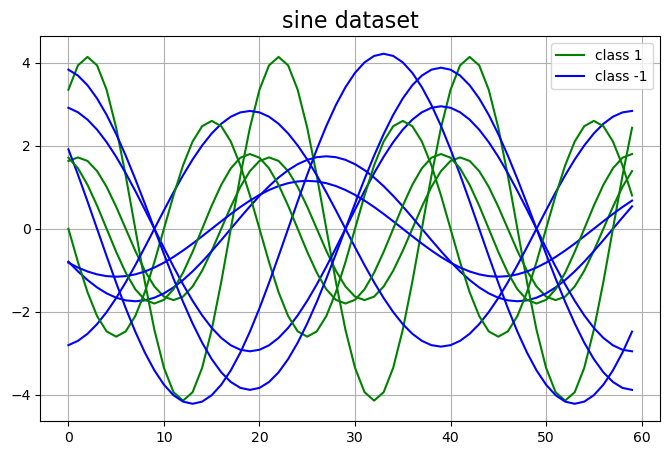

In [3]:
plt.figure(figsize=(8, 5))
for i in range(10):
    if val_label[i] == 1:
        plt.plot(val_data[i,:,0],color='g',label='class 1')
    else:
        plt.plot(val_data[i,:,0],color='b',label='class -1')
handles, labels_legend = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels_legend, handles))
plt.legend(by_label.values(), by_label.keys())
plt.grid()
plt.title("sine dataset", fontsize=16)
plt.show()

epoch =  20, loss_inf = -0.50, training network accuracy = 1.00, training formula accuracy = 1.00
validation network accuracy = 1.00, validation formula accuracy = 1.00
epoch =  40, loss_inf = -2.20, training network accuracy = 1.00, training formula accuracy = 1.00
validation network accuracy = 1.00, validation formula accuracy = 1.00
epoch =  60, loss_inf = -3.62, training network accuracy = 1.00, training formula accuracy = 1.00
validation network accuracy = 1.00, validation formula accuracy = 1.00
epoch =  80, loss_inf = -5.36, training network accuracy = 1.00, training formula accuracy = 1.00
validation network accuracy = 1.00, validation formula accuracy = 1.00
epoch = 100, loss_inf = -5.62, training network accuracy = 1.00, training formula accuracy = 1.00
validation network accuracy = 1.00, validation formula accuracy = 1.00
Total training time is 385.84
Best training formula accuracy is 1.00


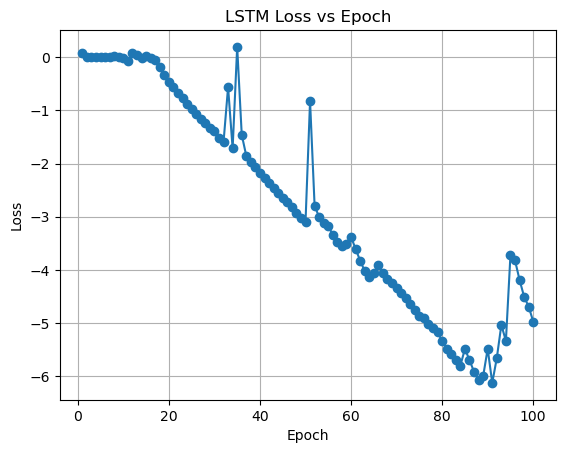

In [4]:
dataset = CustomDataset(train_data, train_label)
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
nsample = train_data.shape[0]
val_nsample = val_data.shape[0]
length = train_data.shape[1]
dim = train_data.shape[2]
nf = dim*3
nc = 1
weight_bi = [1e-3,1e-3,1e-3,1e-3] # weight for bi-modal regularizer
weight_l1 = [1e-3] # weight for L1 regularizer
weight_margin = 1e-1 # weight for margin

# initialize
epochs_inf = 100
relu = torch.nn.ReLU()
stl = SineModel(nf,nc,length,weight_bi,weight_l1)
stl_optimizer = torch.optim.Adam(stl.parameters(), lr=1e-1)

train_losses = {}
stl.train()
total_time = 0
acc_best = 0
for epoch in range(epochs_inf):
    epoch_losses = list()
    for batch_idx, (data_batch, labels_batch) in enumerate(dataloader):
        start_time = time.time()
        stl_optimizer.zero_grad()
        r, reg = stl(data_batch)
        loss_inf = torch.mean(relu(stl.eps-labels_batch*r)) - weight_margin*stl.eps + reg
        loss_inf.backward()
        stl_optimizer.step()
        end_time = time.time()
        total_time += end_time - start_time
        
        epoch_losses.append(loss_inf.detach().item())

    train_losses[epoch] = torch.tensor(epoch_losses).mean()
    loss_log = list(train_losses.values())
    loss_log = [x.item() for x in loss_log]

    if (epoch+1) % 10 == 0:
        with torch.no_grad():
            r_train, _,  = stl(train_data)
            r_train = Clip.apply(r_train)
            acc_train = torch.sum((r_train==train_label))/nsample
            accf_train = stl.accuracy_formula(train_data, train_label)
            r_val, _,  = stl(val_data)
            r_val = Clip.apply(r_val)
            acc = torch.sum((r_val==val_label))/val_nsample
            accf = stl.accuracy_formula(val_data, val_label)
        if accf_train>=acc_best:
            acc_best = accf_train
            torch.save(stl.state_dict(), f'sine_TLINet.pth')
    if (epoch+1) % 20 == 0:
        print('epoch = {:3d}, loss_inf = {:.2f}, training network accuracy = {:.2f}, training formula accuracy = {:.2f}'.format(epoch+1,loss_inf,acc_train,accf_train))
        print('validation network accuracy = {:.2f}, validation formula accuracy = {:.2f}'.format(acc,accf))
    stl_optimizer.zero_grad()
print('Total training time is {:.2f}'.format(total_time))
print('Best training formula accuracy is {:.2f}'.format(acc_best))
plt.plot(range(1, epochs_inf+1), loss_log, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Loss vs Epoch')
plt.grid()
plt.show()

In [4]:
with torch.no_grad():
    stl.load_state_dict(torch.load('sine_TLINet.pth', weights_only=True))
    stl.translate_formula()

G[3,39]F[7,23]x>0.13


In [5]:
random.seed(42)
with open('noisy_sine_dataset.pkl', 'rb') as f:
    train_data, train_label, val_data, val_label = pickle.load(f)

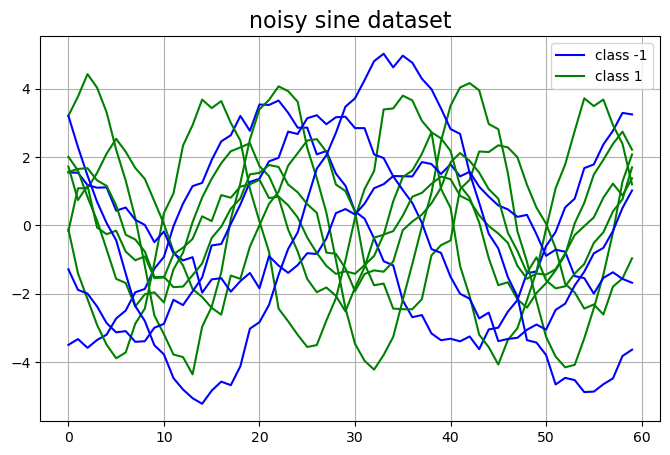

In [6]:
plt.figure(figsize=(8, 5))
for i in range(10):
    if train_label[i] == 1:
        plt.plot(train_data[i,:,0],color='g',label='class 1')
    else:
        plt.plot(train_data[i,:,0],color='b',label='class -1')
handles, labels_legend = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels_legend, handles))
plt.legend(by_label.values(), by_label.keys())
plt.grid()
plt.title("noisy sine dataset", fontsize=16)
plt.show()

epoch =  20, loss_inf = 0.01, training network accuracy = 0.72, training formula accuracy = 0.50
validation network accuracy = 0.97, validation formula accuracy = 0.00
epoch =  40, loss_inf = 0.00, training network accuracy = 0.89, training formula accuracy = 0.50
validation network accuracy = 0.69, validation formula accuracy = 0.00
epoch =  60, loss_inf = 0.01, training network accuracy = 0.81, training formula accuracy = 0.50
validation network accuracy = 0.73, validation formula accuracy = 0.00
epoch =  80, loss_inf = -1.34, training network accuracy = 0.99, training formula accuracy = 0.99
validation network accuracy = 1.00, validation formula accuracy = 1.00
epoch = 100, loss_inf = -2.74, training network accuracy = 1.00, training formula accuracy = 1.00
validation network accuracy = 1.00, validation formula accuracy = 1.00
Total training time is 364.53
Best training formula accuracy is 1.00


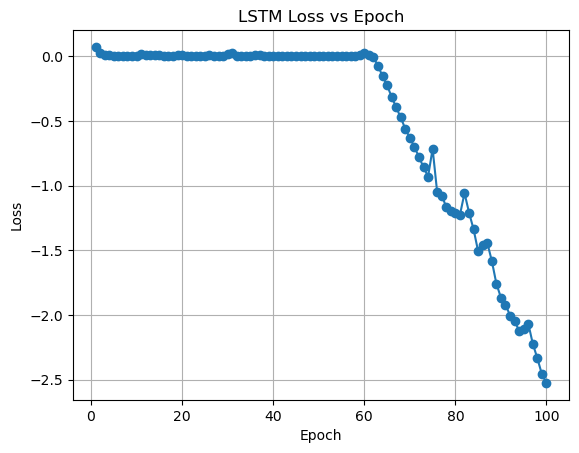

In [4]:
dataset = CustomDataset(train_data, train_label)
batch_size = 64
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
nsample = train_data.shape[0]
val_nsample = val_data.shape[0]
length = train_data.shape[1]
dim = train_data.shape[2]
nf = dim*3
nc = 1
weight_bi = [1e-3,1e-3,1e-3,1e-3] # weight for bi-modal regularizer
weight_l1 = [1e-3] # weight for L1 regularizer
weight_margin = 1e-1 # weight for margin

# initialize
epochs_inf = 100
relu = torch.nn.ReLU()
stl = SineModel(nf,nc,length,weight_bi,weight_l1)
stl_optimizer = torch.optim.Adam(stl.parameters(), lr=1e-1)

train_losses = {}
stl.train()
total_time = 0
acc_best = 0
for epoch in range(epochs_inf):
    epoch_losses = list()
    for batch_idx, (data_batch, labels_batch) in enumerate(dataloader):
        start_time = time.time()
        stl_optimizer.zero_grad()
        r, reg = stl(data_batch)
        loss_inf = torch.mean(relu(stl.eps-labels_batch*r)) - weight_margin*stl.eps + reg
        loss_inf.backward()
        stl_optimizer.step()
        end_time = time.time()
        total_time += end_time - start_time
        
        epoch_losses.append(loss_inf.detach().item())

    train_losses[epoch] = torch.tensor(epoch_losses).mean()
    loss_log = list(train_losses.values())
    loss_log = [x.item() for x in loss_log]

    if (epoch+1) % 10 == 0:
        with torch.no_grad():
            r_train, _,  = stl(train_data)
            r_train = Clip.apply(r_train)
            acc_train = torch.sum((r_train==train_label))/nsample
            accf_train = stl.accuracy_formula(train_data, train_label)
            r_val, _,  = stl(val_data)
            r_val = Clip.apply(r_val)
            acc = torch.sum((r_val==val_label))/val_nsample
            accf = stl.accuracy_formula(val_data, val_label)
        if accf_train>=acc_best:
            acc_best = accf_train
            torch.save(stl.state_dict(), f'noisy_sine_TLINet.pth')
    if (epoch+1) % 20 == 0:
        print('epoch = {:3d}, loss_inf = {:.2f}, training network accuracy = {:.2f}, training formula accuracy = {:.2f}'.format(epoch+1,loss_inf,acc_train,accf_train))
        print('validation network accuracy = {:.2f}, validation formula accuracy = {:.2f}'.format(acc,accf))
    stl_optimizer.zero_grad()
print('Total training time is {:.2f}'.format(total_time))
print('Best training formula accuracy is {:.2f}'.format(acc_best))
plt.plot(range(1, epochs_inf+1), loss_log, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('LSTM Loss vs Epoch')
plt.grid()
plt.show()

In [7]:
with torch.no_grad():
    stl.load_state_dict(torch.load('noisy_sine_TLINet.pth', weights_only=True))
    stl.translate_formula()

G[0,36]F[0,12]x>0.18
